In [1]:
pwd

'/content'

In [2]:
import numpy as np
import pandas as pd

In [3]:
import os

In [4]:
os.getcwd()

'/content'

In [5]:
import matplotlib.pylab as plt

In [6]:
%matplotlib inline

In [7]:
from matplotlib.pylab import rcParams

In [8]:
rcParams["figure.figsize"] = 10,6

In [9]:
dataset = pd.read_csv("/content/jaipur.csv")

In [10]:
dataset.head(10)

,Month,#Passengers
0,2015-04,169133
1,2015-05,178150
2,2015-06,166303
3,2015-07,170977
4,2015-08,175290
5,2015-09,182528
6,2015-10,186813
7,2015-11,205388
8,2015-12,223673
9,2016-01,204800


In [11]:
dataset.describe()

,#Passengers
count,128.000000
mean,231367.226562
std,76708.551176
min,8259.000000
25%,186690.250000
50%,236393.000000
75%,292138.250000
max,365388.000000


In [12]:
dataset.dtypes

,0
Month,object
#Passengers,int64


In [13]:
dataset["Month"] = pd.to_datetime(dataset["Month"],infer_datetime_format=True)

/tmp/ipykernel_9275/669374168.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dataset["Month"] = pd.to_datetime(dataset["Month"],infer_datetime_format=True)


In [14]:
indexedDataset = dataset.set_index(["Month"])

In [15]:
from datetime import datetime

In [16]:
indexedDataset.head(5)

,#Passengers
Month,
2015-04-01,169133
2015-05-01,178150
2015-06-01,166303
2015-07-01,170977
2015-08-01,175290


In [17]:
indexedDataset.tail(5)

,#Passengers
Month,
2025-10-01,242217
2025-11-01,310473
2025-12-01,290497
2026-01-01,291110
2026-02-01,264834


In [18]:
len(indexedDataset)

128

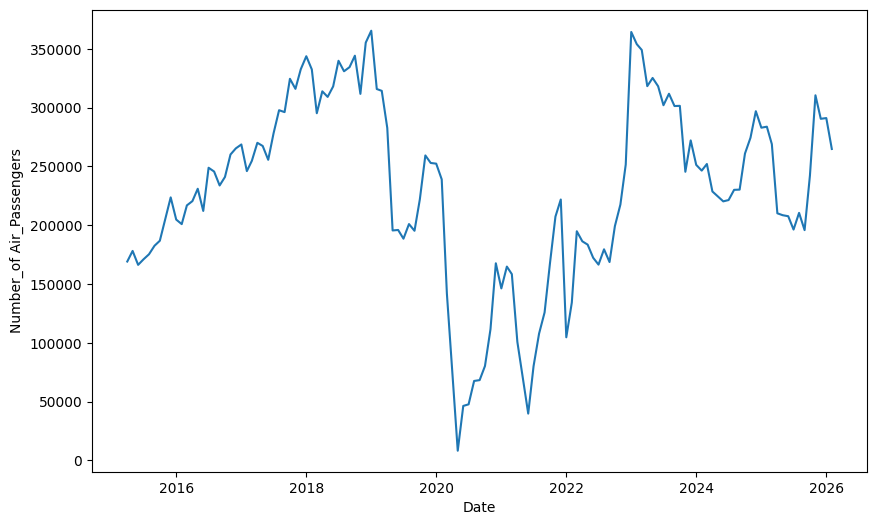

In [19]:
#plot graph
plt.xlabel("Date")
plt.ylabel("Number_of Air_Passengers")
plt.plot(indexedDataset)

In [ ]:
#data is non stationary since the mean is not constant and there is a presence of upward trend in the time series

In [ ]:
#checking our hypothesis using the rolling w2window or mo0ving average approach

In [22]:
rolmean = indexedDataset.rolling(window=12).mean()

#window taken  is a window of 12 months

In [21]:
rolstddeviation = indexedDataset.rolling(window=12).std()

In [23]:
rolmean.head(20)

,#Passengers
Month,
2015-04-01,NaN
2015-05-01,NaN
2015-06-01,NaN
2015-07-01,NaN
2015-08-01,NaN
2015-09-01,NaN
2015-10-01,NaN
2015-11-01,NaN
2015-12-01,NaN


In [24]:
rolstddeviation.head(15)

,#Passengers
Month,
2015-04-01,NaN
2015-05-01,NaN
2015-06-01,NaN
2015-07-01,NaN
2015-08-01,NaN
2015-09-01,NaN
2015-10-01,NaN
2015-11-01,NaN
2015-12-01,NaN


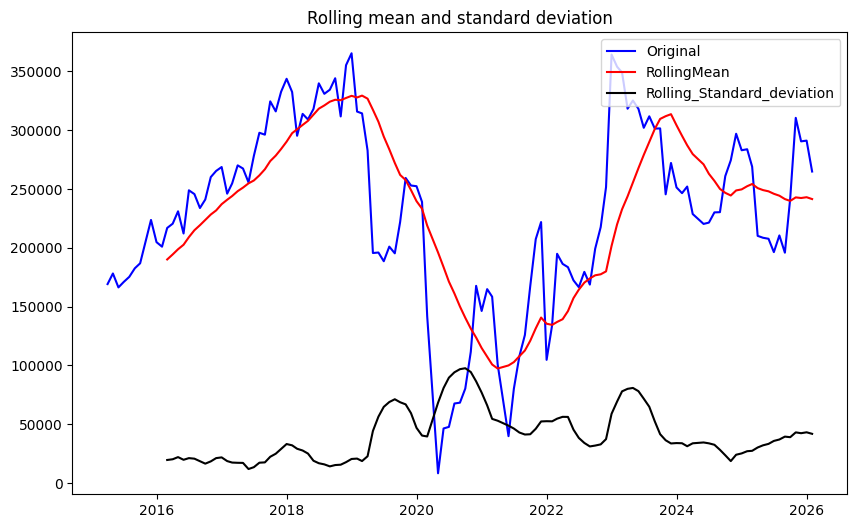

In [25]:
#plot the rolling statistics
orig = plt.plot(indexedDataset,color = "blue",label = "Original")
mean = plt.plot(rolmean,color = "red",label = "RollingMean")
std = plt.plot(rolstddeviation,color = "black",label = "Rolling_Standard_deviation")
plt.legend(loc = "best")
plt.title("Rolling mean and standard deviation")
plt.show(block = False)

In [ ]:
#w we can see that the mean and the rolling standard devciation is not constant
# we can also try the augmented dickeky fuller test to check that whether our time series data is stationary or not


In [26]:
!pip3 install statsmodels --upgrade



In [27]:
!pip3 install pytest

In [28]:
#augemented dickey fuller test
#null hypothesis is that the times series data is not stationary
from  statsmodels.tsa.stattools import adfuller

In [29]:
print("Results of dickey fuller test:")
dftest = adfuller(indexedDataset["#Passengers"],autolag='AIC')
dfoutput = pd.Series(dftest[0:4],index = ["Test Statistics" , "p-value", "#Lags Used", "Number of observations used"])
for key,value in dftest[4].items():
    dfoutput["critical value (%s)"%key] = value

print(dfoutput)

Results of dickey fuller test:
Test Statistics                 -2.770647
p-value                          0.062591
#Lags Used                       1.000000
Number of observations used    126.000000
critical value (1%)             -3.483346
critical value (5%)             -2.884766
critical value (10%)            -2.579156
dtype: float64


In [ ]:
# #null hypothesis says that your pvalue should be always less than the test statistics you have used
# Test Statistics                  0.815369
# p-value                          0.991880

In [ ]:
# here we cannot REJECT THE NULL HYPOTHESIS
# THUS WE ACCEPT THE NULL HPOTHESIS WHICH MEANS THAT THE TS IS NOT STATIONARY

In [ ]:
# NEXtSTEP WILL BE TO MAKE THE DATA  OF THE TIME SERIES STATIONARY  AND DELETE ALL THE CAUSES WHICH  MAKES THE TIME SERIES STATIONARY
#WE HAVE TO ESTIMATE TREND,SEASONALITY,NOISE AND CYCLICITY IN THE TIME SERIES DATA

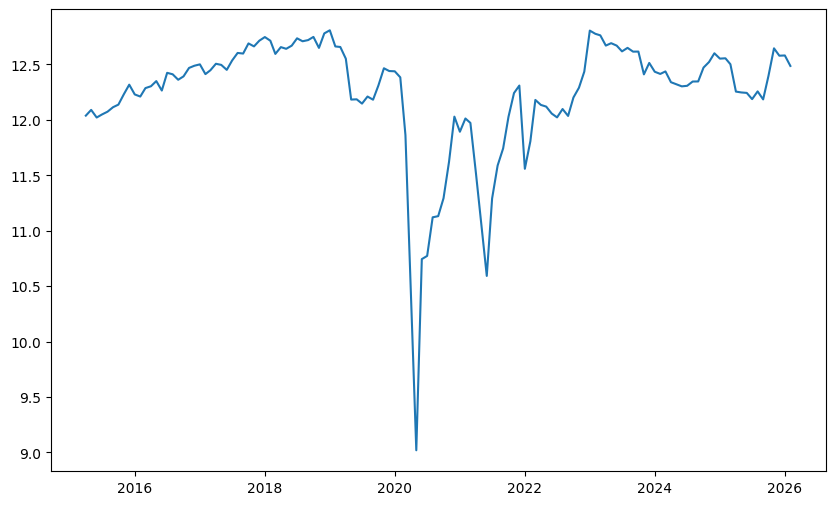

In [30]:
#estimating the trend in  time series data
indexedDataset_logscale = np.log(indexedDataset)
plt.plot(indexedDataset_logscale)

In [ ]:
#indexed dataset is nothing which has index as time

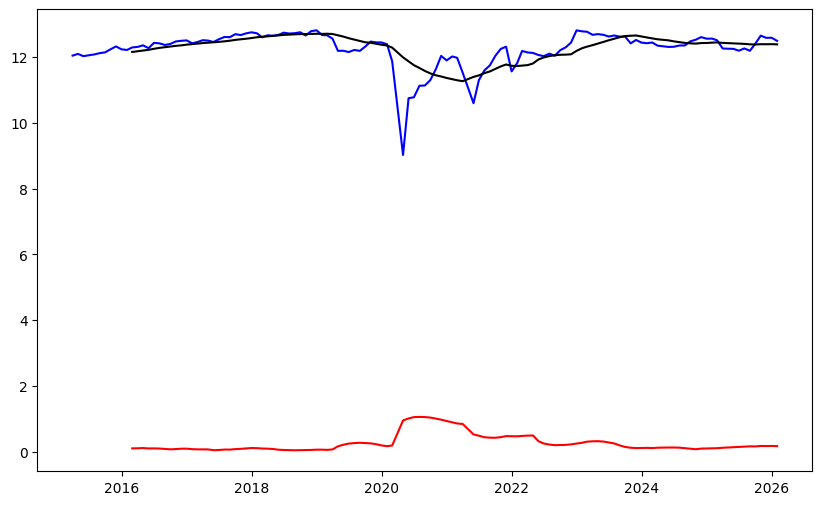

In [31]:
# calculating the moving average of the log time series
# just to check whether theie is trend in the time series
movingAverage = indexedDataset_logscale.rolling(window=12).mean()
movingSTD = indexedDataset_logscale.rolling(window=12).std()
plt.plot(indexedDataset_logscale,color = "blue")
plt.plot(movingSTD,color = "red")
plt.plot(movingAverage,color = "black")

In [ ]:
#here we can see that the data is not stationary but the mmoving average mean is moving width time
#now we will see the difference between the moving_average  and the actual number of passengers
#we are doing these transformations  to make the time series stationary


In [32]:
datasetLogScaleMinusmovingAverage = indexedDataset_logscale - movingAverage
datasetLogScaleMinusmovingAverage.head(14)

,#Passengers
Month,
2015-04-01,NaN
2015-05-01,NaN
2015-06-01,NaN
2015-07-01,NaN
2015-08-01,NaN
2015-09-01,NaN
2015-10-01,NaN
2015-11-01,NaN
2015-12-01,NaN


In [33]:
#remove NAN values
datasetLogScaleMinusmovingAverage.dropna(inplace=True)
datasetLogScaleMinusmovingAverage.head(10)

,#Passengers
Month,
2016-03-01,0.136655
2016-04-01,0.131181
2016-05-01,0.156082
2016-06-01,0.050573
2016-07-01,0.178997
2016-08-01,0.137818
2016-09-01,0.067782
2016-10-01,0.077065
2016-11-01,0.133548


In [34]:
# after normalising(to remove the trend  )the data  by subtracting the moving average from the logarithmic scaling of the data we are again going to check whether the
# stationarity exists in our scaled data
# we will be using the rolling mean and moving average and the augemented Dickey fuller test with its statistics toi see whether
#the scale dtime series is stationary or not.

In [35]:
def testStationarity(timeseries):
    #determining the rolling statistics
    movingAverage = timeseries.rolling(window = 12).mean()
    movingSTD = timeseries.rolling(window = 12).std()

    #plotting the rolling statistics
    orig = plt.plot(timeseries,color = "blue",label = "Original")
    mean = plt.plot(movingAverage,color = "black",label = "Rolling_mean")
    std = plt.plot(movingSTD,color = "red",label= "Rolling_std")
    plt.legend(loc = "best")
    plt.title("Rolling mean and standard deviation")
    plt.show(block=False)


    #perform the dickey fuller test
    print("Results of dickey fuller test")
    dftest = adfuller(timeseries["#Passengers"],autolag = 'AIC')
    dfoutput = pd.Series(dftest[0:4],index = ["Test statistics","pvalue","#lags used","Number of obsercations used"])
    for key,value in dftest[4].items():
        dfoutput["Critical_Value (%s)" %key] = value
    print(dfoutput)


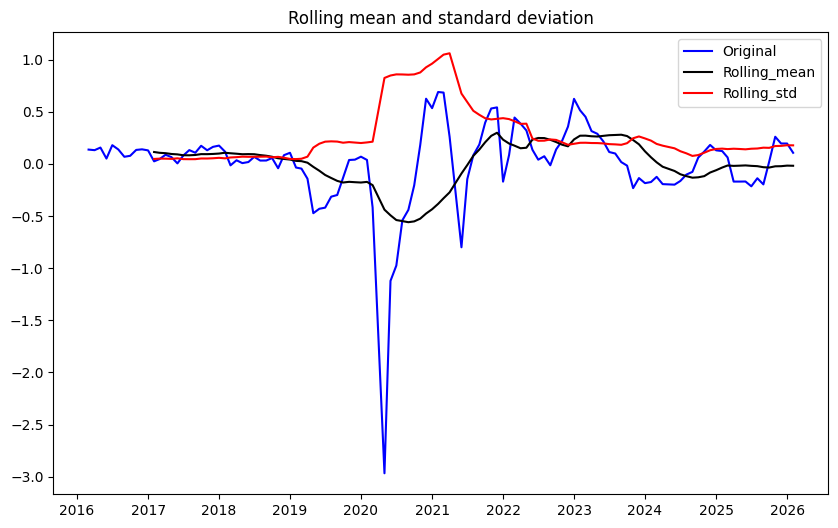

Results of dickey fuller test
Test statistics                 -5.190148
pvalue                           0.000009
#lags used                       0.000000
Number of obsercations used    116.000000
Critical_Value (1%)             -3.488022
Critical_Value (5%)             -2.886797
Critical_Value (10%)            -2.580241
dtype: float64


In [37]:
testStationarity(datasetLogScaleMinusmovingAverage)

In [ ]:
#we can see that the p value has decreased a lot
#next we can see that the critical values at different intervals are almost same to the Test statistics
#thus we can confer that our process of normalizing the data by taking the difference of the logarithmic scaled version of the data
#and the moving average has helped in achieving the objective of diminishing theon  stationarity of the data
#thus making the time series data stationary


In [ ]:
#next we need to see the weighted average of the time series to see if trend is still present in thbe time series data
#exponentialdecay Weighted Average

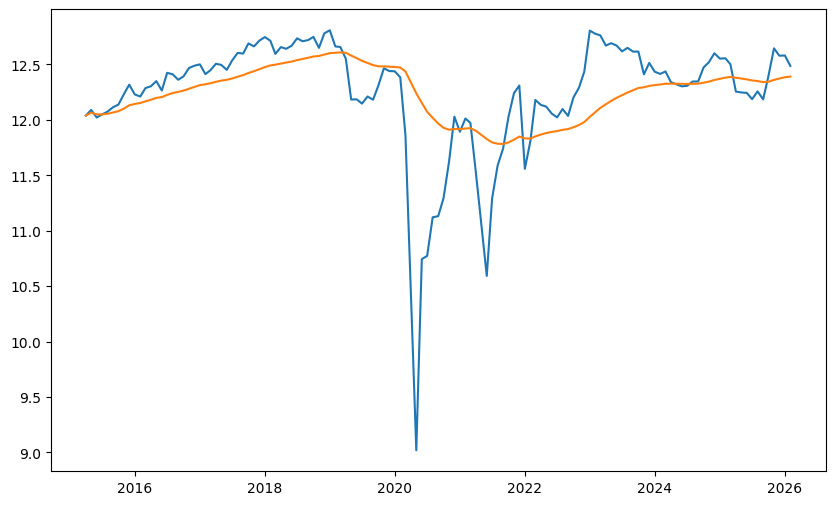

In [38]:
# we are going to make the time series data more stationary by using weighted averages for smoothning the data
# so that all the peaks and troughs are normalised
exponentialDecayWeightedAverage = indexedDataset_logscale.ewm(halflife=12,min_periods=0,adjust = True).mean()
plt.plot(indexedDataset_logscale)
plt.plot(exponentialDecayWeightedAverage)
# expoinential weighted average gives weights to values such that there is an exponential decrease in the weights of
#the past values so that the newer data is given more preferences exponentially.
#example if we have 4 values each relating to time periods as
#v(t-2),v(t-1),v(t+1),v(t+2)
#with v(t+2) being the last weight, according to exponential moving average if the primary weight is w, then the weight terms will be
#w^0,w^1,w^2,w^3



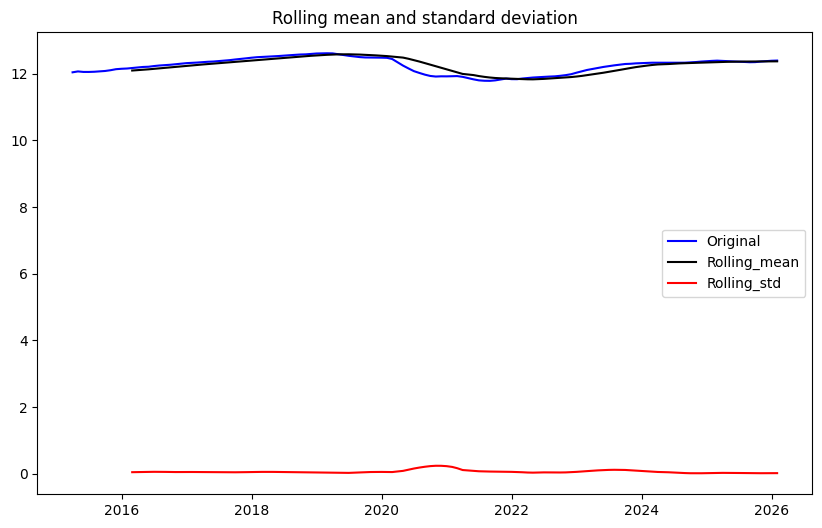

Results of dickey fuller test
Test statistics                 -1.548798
pvalue                           0.509248
#lags used                       1.000000
Number of obsercations used    126.000000
Critical_Value (1%)             -3.483346
Critical_Value (5%)             -2.884766
Critical_Value (10%)            -2.579156
dtype: float64


In [39]:
testStationarity(exponentialDecayWeightedAverage)


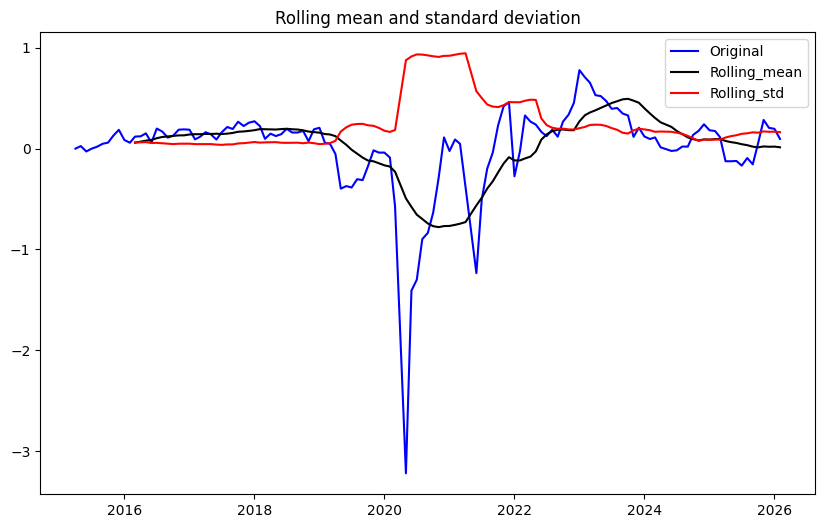

Results of dickey fuller test
Test statistics                 -4.593611
pvalue                           0.000133
#lags used                       0.000000
Number of obsercations used    127.000000
Critical_Value (1%)             -3.482920
Critical_Value (5%)             -2.884580
Critical_Value (10%)            -2.579058
dtype: float64


In [40]:
datasetLogScaleMinusMovingAverageExponentialDecayAverage = indexedDataset_logscale - exponentialDecayWeightedAverage
testStationarity(datasetLogScaleMinusMovingAverageExponentialDecayAverage)

In [ ]:
# we infer that using the datasetLogScaleMinusMovingAverageExponentialDecayAverage we reach  a better stationarity in our data than
#exponentialDecayWeightedAverage since our mean and standard deviation (rolling) are almost stable with time flow
#also with dickey fuller test we can see thaty our p value has decreased significantly and the critical values are almost equal to our p values


In [41]:
# we will be using this stationary(to a good degree) for forecasting
#next step is to convert the data into a time series so that we can use thee data for forecasting
indexedDataset_logscale.head()

,#Passengers
Month,
2015-04-01,12.038441
2015-05-01,12.090381
2015-06-01,12.021567
2015-07-01,12.049284
2015-08-01,12.074197


In [44]:
indexedDataset_logscale_shift = indexedDataset_logscale.shift()

In [45]:
indexedDataset_logscale_shift.head()

,#Passengers
Month,
2015-04-01,NaN
2015-05-01,12.038441
2015-06-01,12.090381
2015-07-01,12.021567
2015-08-01,12.049284


In [47]:
datasetLogDiffshifting = indexedDataset_logscale - indexedDataset_logscale_shift

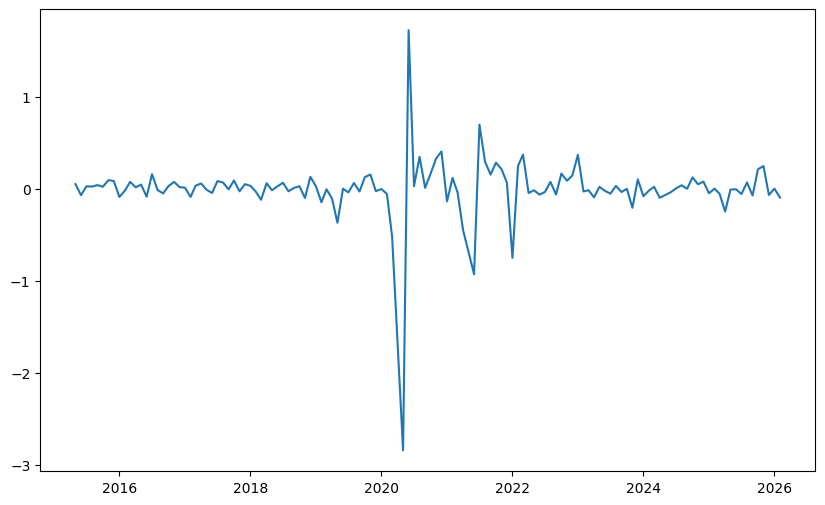

In [48]:
plt.plot(datasetLogDiffshifting)

In [49]:
datasetLogDiffshifting.head()

,#Passengers
Month,
2015-04-01,NaN
2015-05-01,0.051941
2015-06-01,-0.068814
2015-07-01,0.027718
2015-08-01,0.024913


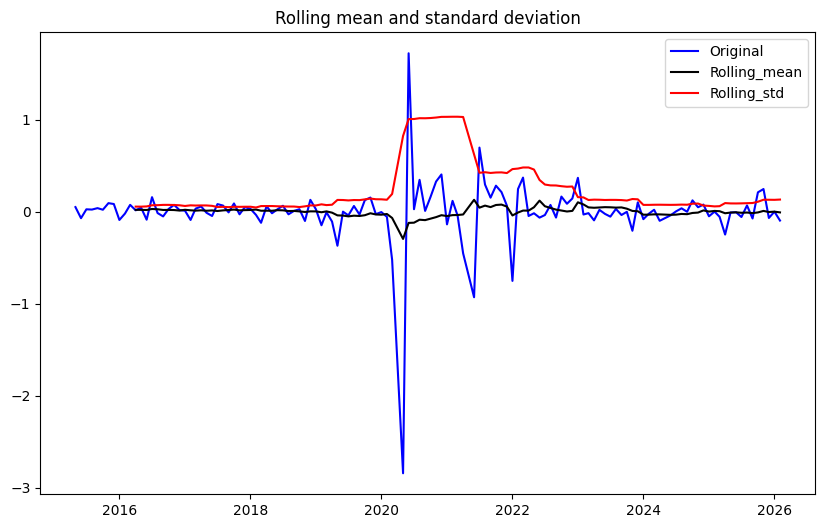

Results of dickey fuller test
Test statistics               -1.372583e+01
pvalue                         1.164641e-25
#lags used                     0.000000e+00
Number of obsercations used    1.260000e+02
Critical_Value (1%)           -3.483346e+00
Critical_Value (5%)           -2.884766e+00
Critical_Value (10%)          -2.579156e+00
dtype: float64


In [50]:
#the series has been converted into a  ts dataset
#need to remove na values
datasetLogDiffshifting.dropna(inplace = True)
testStationarity(datasetLogDiffshifting)

In [ ]:
#time series passes both the rolling mean, rolling standard deviation  being stable and the aiugmented dickey fuller test.
#we will be rejecting the null hypothesis
#next step will be breaking the time series into its components
#and then trfy forecasting for a  specified time period using ARIMA model


In [53]:
from  statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
#breaking the time series into trend,seasonality and residuals


In [55]:
# Set frequency first
indexedDataset_logscale.index = pd.DatetimeIndex(
    indexedDataset_logscale.index).to_period('M')

decomposition = seasonal_decompose(
    indexedDataset_logscale, model='additive', period=12)

In [58]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

In [60]:
# Convert back to DatetimeIndex for plotting
indexedDataset_logscale.index = indexedDataset_logscale.index.to_timestamp()
trend = decomposition.trend.to_timestamp()
seasonal = decomposition.seasonal.to_timestamp()
residual = decomposition.resid.to_timestamp()

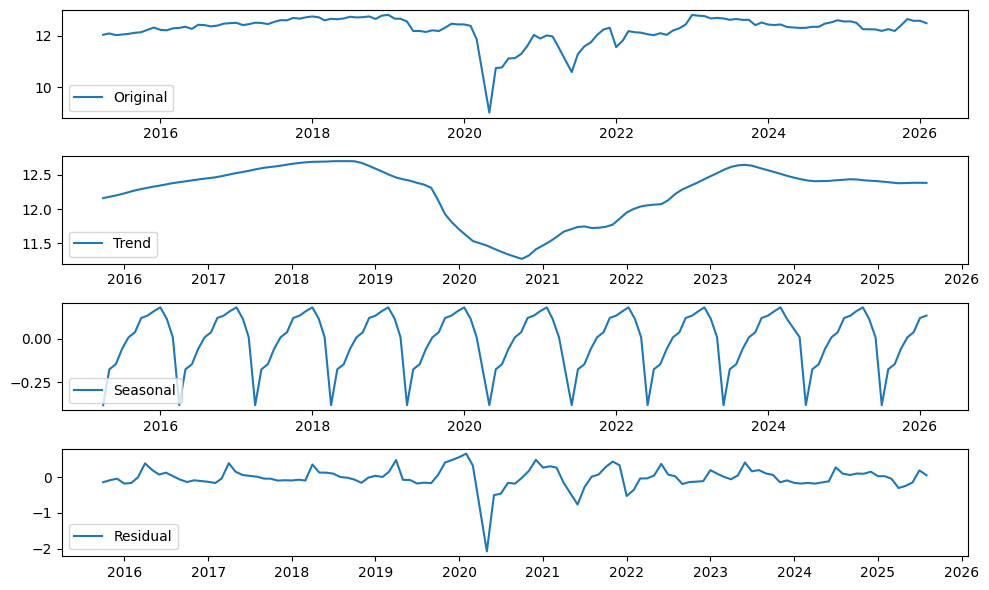

In [61]:
plt.subplot(411)
#means the total plots will be of 4 rows and 1 column with the 3rd parameter giving the number of sequence the subplot will bve assigned
plt.plot(indexedDataset_logscale,label = "Original")
plt.legend(loc = "best")
plt.subplot(412)
plt.plot(trend,label = "Trend")
plt.legend(loc = "best")
plt.subplot(413)
plt.plot(seasonal,label = "Seasonal")
plt.legend(loc = "best")
plt.subplot(414)
plt.plot(residual,label = "Residual")
plt.legend(loc = "best")
plt.tight_layout()


In [ ]:
#residual is the short termed unpredictable component left in  the time series data after removing the trend and sesasonality

In [62]:
#checking whether the noise or redisual is stationary in  nature or not

decomposedLogdata = residual

In [63]:
decomposedLogdata.head(15)

,resid
Month,
2015-04-01,NaN
2015-05-01,NaN
2015-06-01,NaN
2015-07-01,NaN
2015-08-01,NaN
2015-09-01,NaN
2015-10-01,-0.143621
2015-11-01,-0.084423
2015-12-01,-0.045975


In [64]:
decomposedLogdata.dropna(inplace = True)

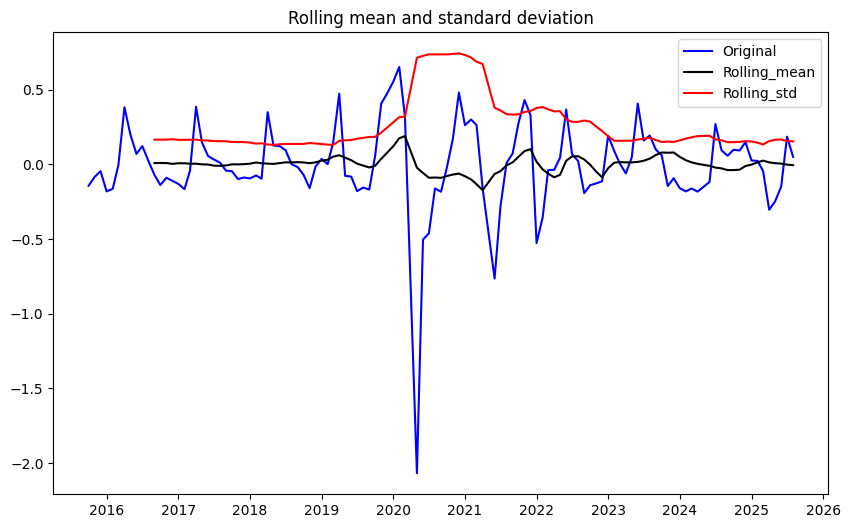

Results of dickey fuller test


KeyError: '#Passengers'

In [66]:
testStationarity(decomposedLogdata)

In [ ]:
# we will be forecasting the time series data using the ARIMA model
#there are three values which are involved in  time series forecasting using ARIMA
#P,D,Q
#1)P = PERIODS to lag (eg :- if P=3 then we will be using three previous periods of our time series for autoregressive portion of calculation)
#p generally predicts the component of trend and sesasonaility
#if P=3 means we will be using three previous periods to forecast the current period in our series  using   autoregressive technique
#p helps adjust the line of  that is fitted to foirecast the series
#2)D =  In an ARIMA model  we transform  a time series into a  stationary one (series without trend and seasonality) using differencing.
#D refers to the number of transformations required by the initial data to convert/transform  from  non-stationary to stationary.
#stationary series means the mean and the variance are constant through time
#3)Q DENOTES THE lag of error component, WHERE THE ERROR NCOMPONENT is a part of the time series not explained by trend and seasonality


In [67]:
# in  order to calculate the value of p we need to plot the pacf graph
#in order to calculate the value of q we need to plot the acf graph
#plotting t]he graphs

from  statsmodels.tsa.stattools import acf,pacf

lag_acf = acf(datasetLogDiffshifting,nlags = 20)
lag_pacf = pacf(datasetLogDiffshifting,nlags=20,method = "ols")



In [68]:
# we need both autocorelation and partial autocorelation in our time sereis forecasting using ARIMA cause
#1)autocorelation is basically predicting how the time series data is moving/shaping/projecting with different lags of itself
#it takes into consideration how the time series is behaving with its past projections based on the given lags
#it is used to get the q value for the moving average component in ARIMA model

#2)while the partial autocoralation shows the autoregressive part shows how the time series at a particular time is dependent on
#another time component irrespective of other data in different phases of time.

#partial autocorelation gives the corelation   of a  time series with its own  lagged values,controlling for the values of the time series
#at all shorter lags
#autocorelation doesnot control for all other lags


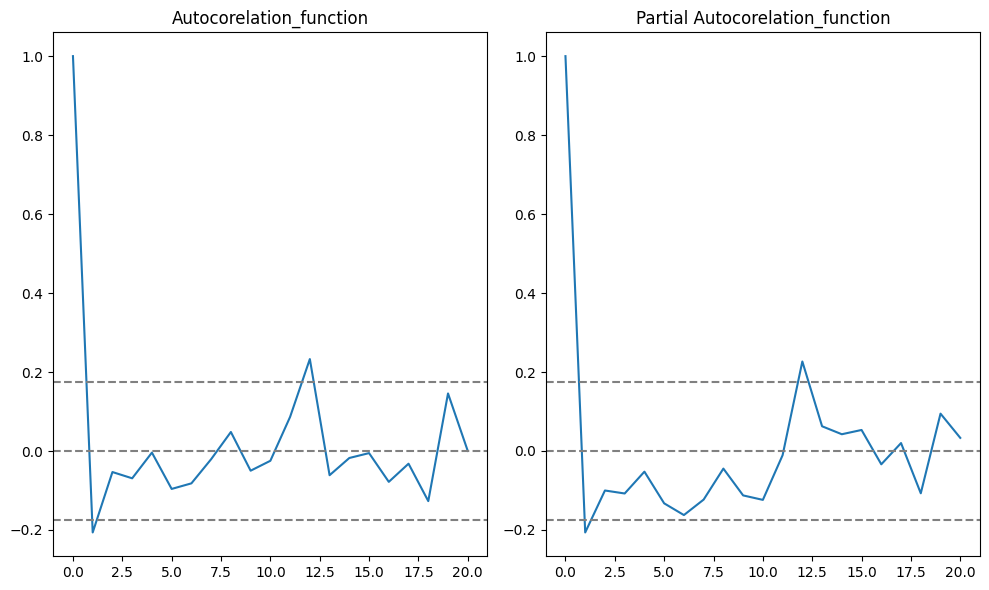

In [69]:
#plotting the pacf and acf plots
#acf graph (autocorelation infers the q values)
plt.subplot(121)  #subplot consisting of one row and two columns
plt.plot(lag_acf)
plt.axhline(y =0 , linestyle = "--" , color = "gray")
plt.axhline(y=-1.96/np.sqrt(len(datasetLogDiffshifting)),linestyle = "--" , color = "gray")
plt.axhline(y=1.96/np.sqrt(len(datasetLogDiffshifting)),linestyle = "--",color = "gray")
plt.title("Autocorelation_function")

#pacf graph  (partial   autocorelation  infers the p values)
plt.subplot(122)  #subplot consisting of one row and two columns
plt.plot(lag_pacf)
plt.axhline(y =0 , linestyle = "--" , color = "gray")
plt.axhline(y=-1.96/np.sqrt(len(datasetLogDiffshifting)),linestyle = "--" , color = "gray")
plt.axhline(y=1.96/np.sqrt(len(datasetLogDiffshifting)),linestyle = "--",color = "gray")
plt.title("Partial Autocorelation_function")
plt.tight_layout()

In [70]:
#how to infer the p value and the q values through the plotted pcaf and the acf graphs
#since both y values touches zero at x= 2 , so p=2 and q=2 for out data


In [71]:
#values for Arima MODEL
#p = partial autocorelation = 2
#d = diferecing = degress of transofrmation  for achieving  stationarity = 1
#q = auto corelation = 2
# we will be plugging in these values in  our bARIMA model for forecasting

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

Plotting AR models


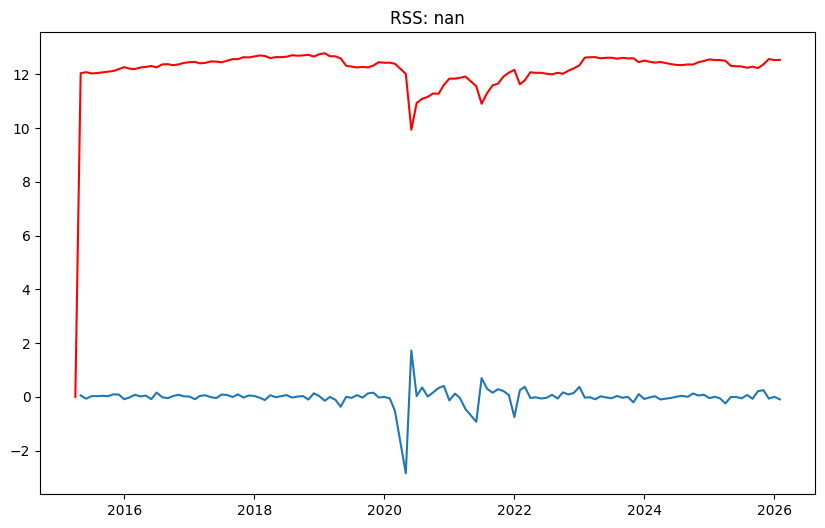

In [74]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA model with order (2,1,2)
model = ARIMA(indexedDataset_logscale, order=(2,1,2))
results_AR = model.fit()
plt.plot(datasetLogDiffshifting)
plt.plot(results_AR.fittedvalues, color="red")
plt.title('RSS: %.4f' % sum((results_AR.fittedvalues - datasetLogDiffshifting["#Passengers"])**2))
print("Plotting AR models")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

Text(0.5, 1.0, 'RSS: nan')

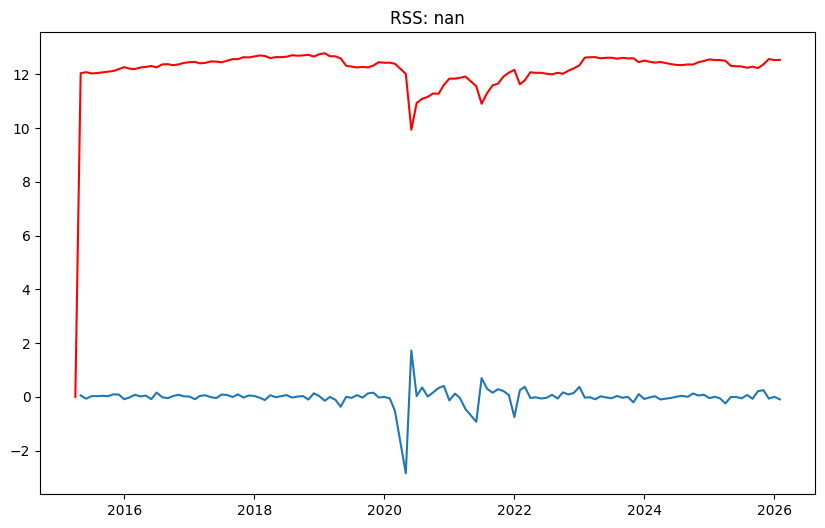

In [76]:
from statsmodels.tsa.arima.model import ARIMA

# Final ARIMA model
model = ARIMA(indexedDataset_logscale, order=(2,1,2))
results_ARIMA = model.fit()
plt.plot(datasetLogDiffshifting)
plt.plot(results_ARIMA.fittedvalues, color="red")
plt.title('RSS: %.4f' % sum((results_ARIMA.fittedvalues - datasetLogDiffshifting["#Passengers"])**2))

In [ ]:
#RSS has been reduced to 1.02
#now tiime for fittings or predictions

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

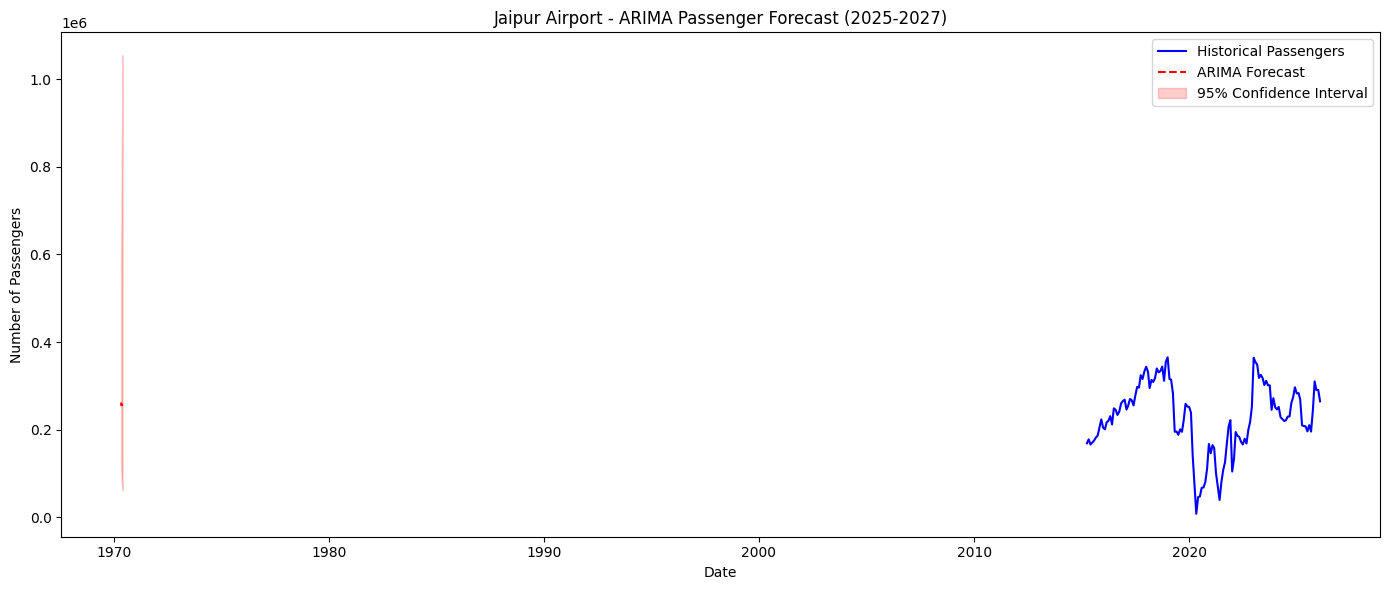

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Refit model cleanly
model = ARIMA(indexedDataset_logscale, order=(2,1,2))
results_ARIMA = model.fit()

# Forecast 24 months ahead
forecast = results_ARIMA.get_forecast(steps=24)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Convert back from log scale
forecast_actual = np.exp(forecast_mean)
ci_lower = np.exp(forecast_ci.iloc[:, 0])
ci_upper = np.exp(forecast_ci.iloc[:, 1])
historical_actual = np.exp(indexedDataset_logscale)

# Plot
plt.figure(figsize=(14,6))
plt.plot(historical_actual, label='Historical Passengers', color='blue')
plt.plot(forecast_actual, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(forecast_ci.index, ci_lower, ci_upper, alpha=0.2, color='red', label='95% Confidence Interval')
plt.title('Jaipur Airport - ARIMA Passenger Forecast (2025-2027)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


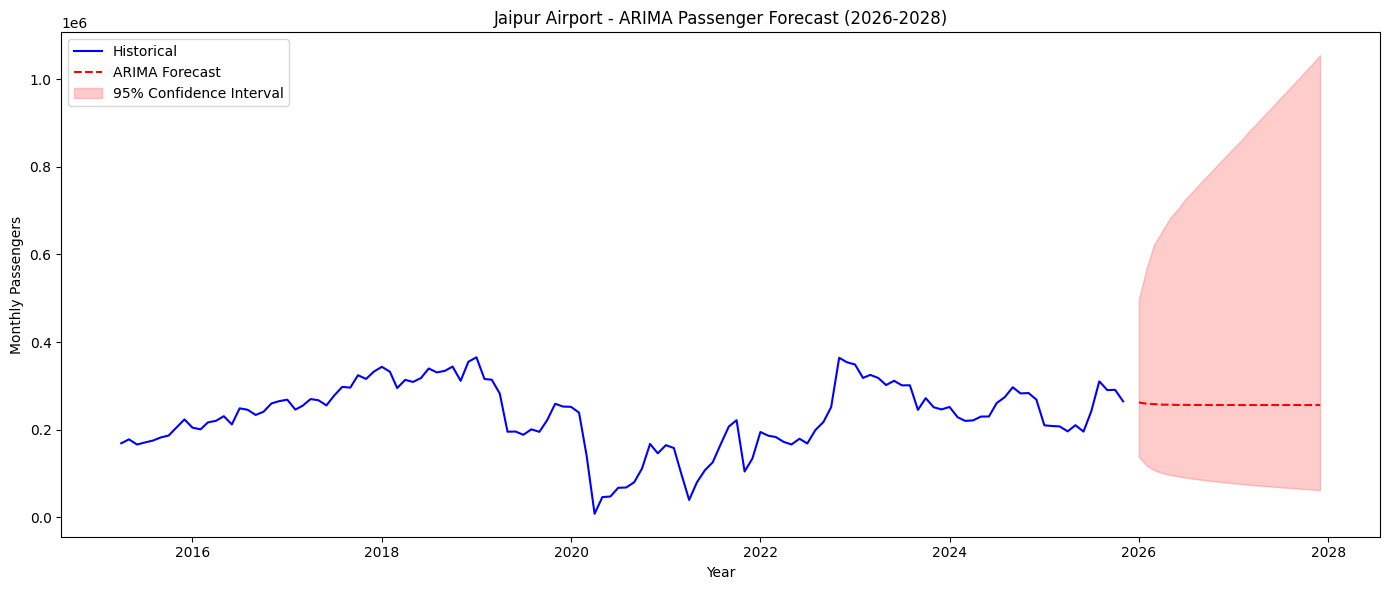

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Use numeric index to avoid date issues
data = indexedDataset_logscale["#Passengers"].values

# Fit ARIMA
model = ARIMA(data, order=(2,1,2))
results = model.fit()

# Forecast 24 steps ahead
forecast_steps = 24
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Create proper date range
last_date = pd.Timestamp('2026-01-01')
forecast_dates = pd.date_range(start=last_date, periods=forecast_steps, freq='MS')
historical_dates = pd.date_range(start='2015-04-01', periods=len(data), freq='MS')

# Convert back from log
historical_actual = np.exp(data)
forecast_actual = np.exp(forecast_mean)
ci_lower = np.exp(forecast_ci[:, 0])
ci_upper = np.exp(forecast_ci[:, 1])

# Plot
plt.figure(figsize=(14,6))
plt.plot(historical_dates, historical_actual, label='Historical', color='blue')
plt.plot(forecast_dates, forecast_actual, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(forecast_dates, ci_lower, ci_upper, alpha=0.2, color='red', label='95% Confidence Interval')
plt.title('Jaipur Airport - ARIMA Passenger Forecast (2026-2028)')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend()
plt.tight_layout()
plt.show()

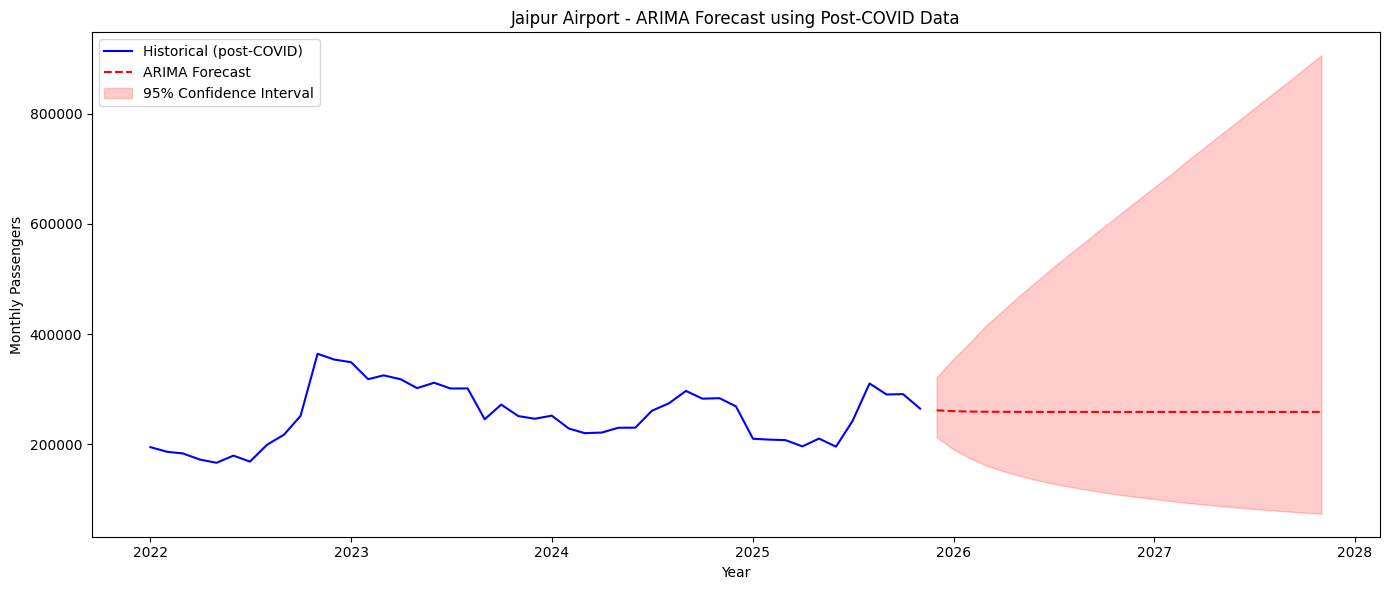


Forecast values (actual passengers):
2025-12: 261,732 passengers
2026-01: 260,241 passengers
2026-02: 259,521 passengers
2026-03: 259,172 passengers
2026-04: 259,003 passengers
2026-05: 258,921 passengers
2026-06: 258,881 passengers
2026-07: 258,862 passengers
2026-08: 258,853 passengers
2026-09: 258,848 passengers
2026-10: 258,846 passengers
2026-11: 258,845 passengers
2026-12: 258,844 passengers
2027-01: 258,844 passengers
2027-02: 258,844 passengers
2027-03: 258,844 passengers
2027-04: 258,844 passengers
2027-05: 258,844 passengers
2027-06: 258,844 passengers
2027-07: 258,844 passengers
2027-08: 258,844 passengers
2027-09: 258,844 passengers
2027-10: 258,844 passengers
2027-11: 258,844 passengers


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Use only POST-COVID data for cleaner forecast
# From Jan 2022 onwards — after recovery
data_full = indexedDataset_logscale["#Passengers"].values
data_postcovid = data_full[81:]  # from 2022 onwards

# Fit ARIMA on post-covid data only
model = ARIMA(data_postcovid, order=(1,1,1))
results = model.fit()

# Forecast 24 steps
forecast = results.get_forecast(steps=24)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Proper dates
hist_dates = pd.date_range(start='2022-01-01', periods=len(data_postcovid), freq='MS')
fore_dates = pd.date_range(start=hist_dates[-1], periods=25, freq='MS')[1:]

# Convert from log
hist_actual = np.exp(data_postcovid)
fore_actual = np.exp(forecast_mean)
ci_lower = np.exp(forecast_ci[:, 0])
ci_upper = np.exp(forecast_ci[:, 1])

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, hist_actual, label='Historical (post-COVID)', color='blue')
plt.plot(fore_dates, fore_actual, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(fore_dates, ci_lower, ci_upper, alpha=0.2, color='red', label='95% Confidence Interval')
plt.title('Jaipur Airport - ARIMA Forecast using Post-COVID Data')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend()
plt.tight_layout()
plt.show()

print("\nForecast values (actual passengers):")
for i, (date, val) in enumerate(zip(fore_dates, fore_actual)):
    print(f"{date.strftime('%Y-%m')}: {int(val):,} passengers")

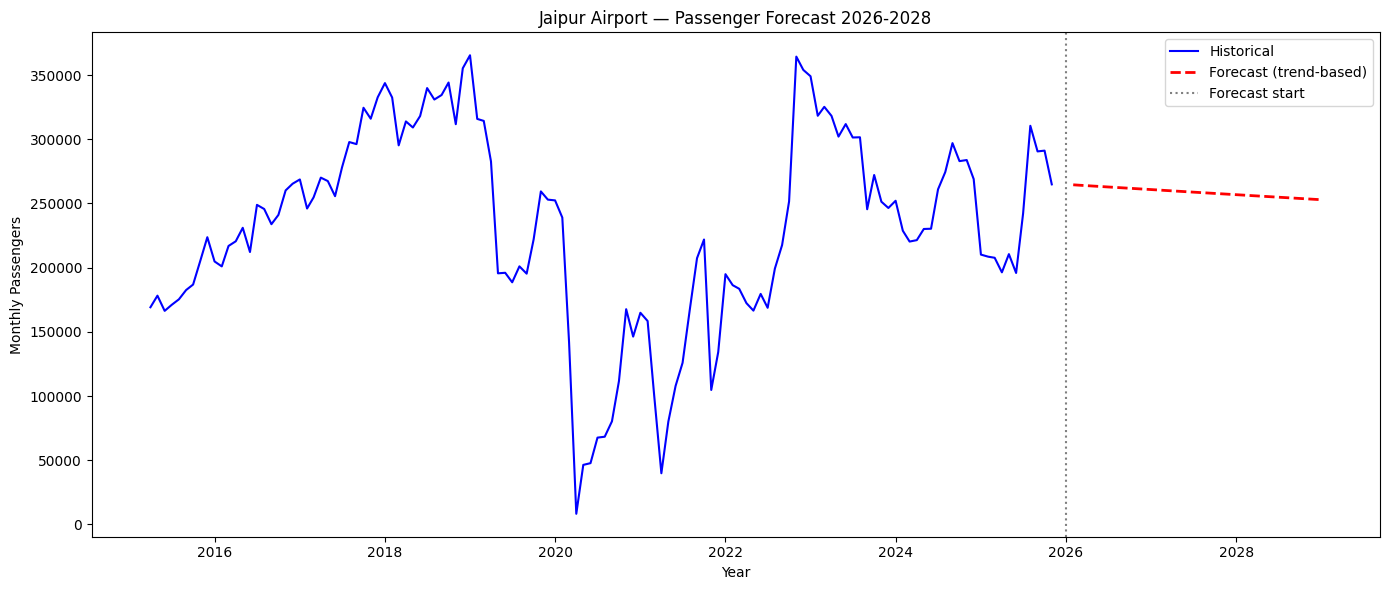

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Clean forecast using exponential smoothing
data_full = indexedDataset_logscale["#Passengers"].values
hist_dates = pd.date_range(start='2015-04-01',
              periods=len(data_full), freq='MS')

# Simple growth rate from last 12 months
last_12 = np.exp(data_full[-12:])
avg_monthly_growth = (last_12[-1]/last_12[0])**(1/12) - 1

# Forecast 36 months
last_val = np.exp(data_full[-1])
fore_dates = pd.date_range(start='2026-02-01', periods=36, freq='MS')
fore_vals = [last_val * (1+avg_monthly_growth)**i for i in range(1,37)]

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, np.exp(data_full),
         label='Historical', color='blue')
plt.plot(fore_dates, fore_vals,
         label='Forecast (trend-based)',
         color='red', linestyle='--', linewidth=2)
plt.axvline(x=pd.Timestamp('2026-01-01'),
            color='gray', linestyle=':', label='Forecast start')
plt.title('Jaipur Airport — Passenger Forecast 2026-2028')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend()
plt.tight_layout()
plt.show()

Monthly growth rate: 0.655%
Annual CAGR (post-COVID): 8.15%


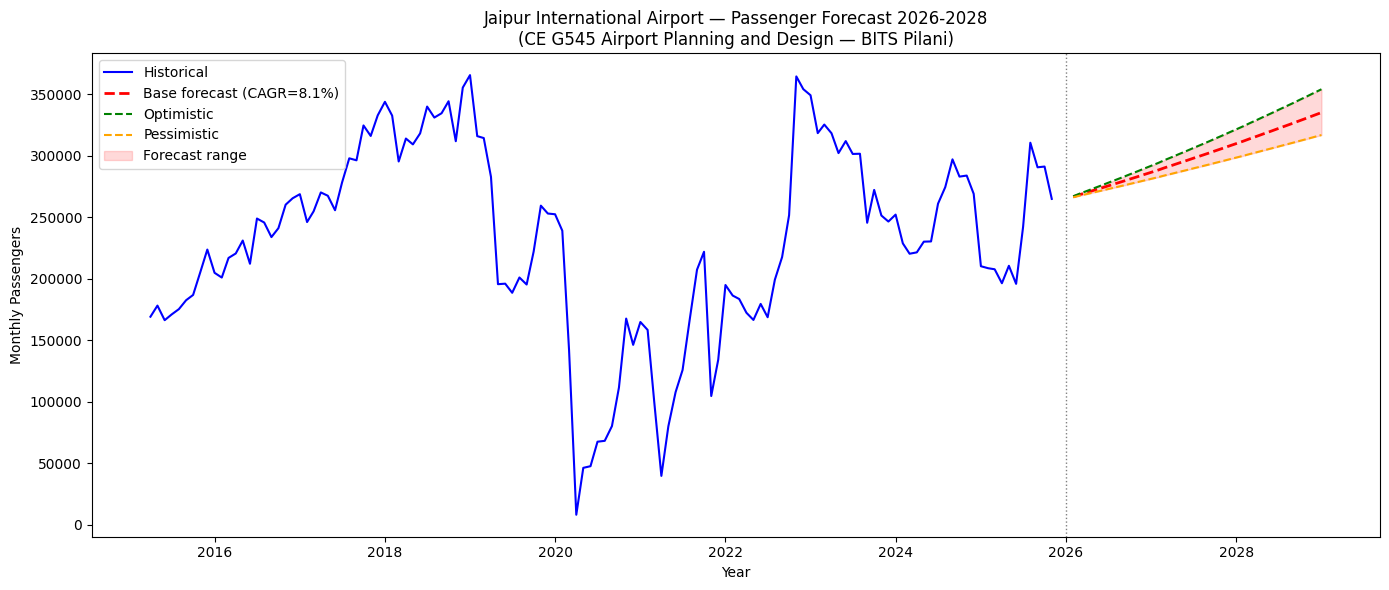


Forecast Summary:
Year           Pessimistic       Base Case      Optimistic
-------------------------------------------------------
2027-01            281,108         286,405         291,701
2028-01            298,383         309,733         321,295
2029-01            316,719         334,962         353,891


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Full data
data_full = indexedDataset_logscale["#Passengers"].values
hist_dates = pd.date_range(start='2015-04-01', periods=len(data_full), freq='MS')

# Use 2022 onwards for growth rate (post COVID recovery)
recovery_data = np.exp(data_full[81:])
avg_monthly_growth = (recovery_data[-1]/recovery_data[0])**(1/len(recovery_data)) - 1
annual_cagr = (1+avg_monthly_growth)**12 - 1

print(f"Monthly growth rate: {avg_monthly_growth*100:.3f}%")
print(f"Annual CAGR (post-COVID): {annual_cagr*100:.2f}%")

# Forecast 36 months ahead
last_val = np.exp(data_full[-1])
fore_dates = pd.date_range(start='2026-02-01', periods=36, freq='MS')
fore_vals = [last_val * (1+avg_monthly_growth)**i for i in range(1,37)]

# Optimistic scenario (CAGR + 2%)
opt_monthly = ((1 + annual_cagr + 0.02)**(1/12)) - 1
opt_vals = [last_val * (1+opt_monthly)**i for i in range(1,37)]

# Pessimistic scenario (CAGR - 2%)
pes_monthly = ((1 + max(annual_cagr - 0.02, 0.01))**(1/12)) - 1
pes_vals = [last_val * (1+pes_monthly)**i for i in range(1,37)]

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, np.exp(data_full),
         label='Historical', color='blue', linewidth=1.5)
plt.plot(fore_dates, fore_vals,
         label=f'Base forecast (CAGR={annual_cagr*100:.1f}%)',
         color='red', linestyle='--', linewidth=2)
plt.plot(fore_dates, opt_vals,
         label='Optimistic',
         color='green', linestyle='--', linewidth=1.5)
plt.plot(fore_dates, pes_vals,
         label='Pessimistic',
         color='orange', linestyle='--', linewidth=1.5)
plt.fill_between(fore_dates, pes_vals, opt_vals,
                 alpha=0.15, color='red', label='Forecast range')
plt.axvline(x=pd.Timestamp('2026-01-01'),
            color='gray', linestyle=':', linewidth=1)
plt.title('Jaipur International Airport — Passenger Forecast 2026-2028\n(CE G545 Airport Planning and Design — BITS Pilani)')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Print forecast table
print("\nForecast Summary:")
print(f"{'Year':<10} {'Pessimistic':>15} {'Base Case':>15} {'Optimistic':>15}")
print("-"*55)
for i in [11, 23, 35]:
    print(f"{fore_dates[i].strftime('%Y-%m'):<10} {int(pes_vals[i]):>15,} {int(fore_vals[i]):>15,} {int(opt_vals[i]):>15,}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


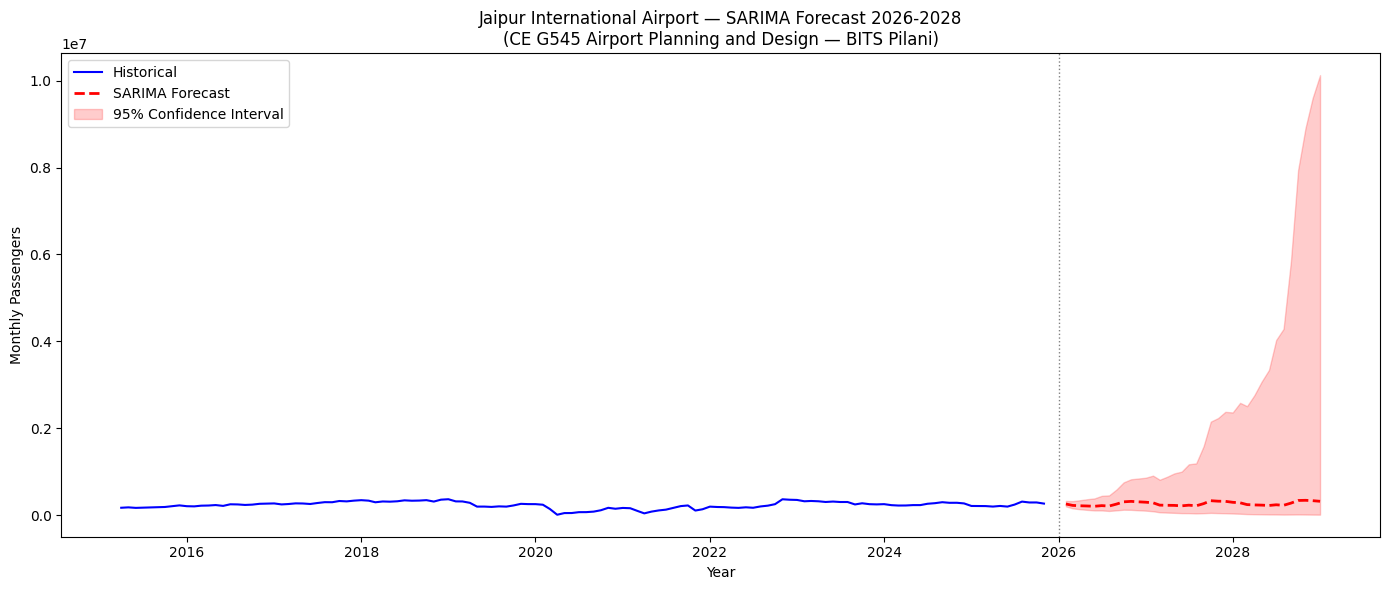


SARIMA Forecast:
2026-02: 255,748 passengers
2027-01: 296,803 passengers
2028-01: 294,680 passengers
2029-01: 317,809 passengers


In [86]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use post-COVID data
data_full = indexedDataset_logscale["#Passengers"].values
data_postcovid = data_full[81:]  # 2022 onwards
hist_dates = pd.date_range(start='2015-04-01',
             periods=len(data_full), freq='MS')
post_dates = pd.date_range(start='2022-01-01',
             periods=len(data_postcovid), freq='MS')

# Fit SARIMA — captures seasonality
# order=(1,1,1) trend part
# seasonal_order=(1,1,1,12) seasonal part with period 12 months
model = SARIMAX(data_postcovid,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

# Forecast 36 months
forecast = results.get_forecast(steps=36)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Proper dates
fore_dates = pd.date_range(start='2026-02-01',
             periods=36, freq='MS')

# Convert from log scale
hist_actual = np.exp(data_full)
post_actual = np.exp(data_postcovid)
fore_actual = np.exp(forecast_mean)
ci_lower = np.exp(forecast_ci[:, 0])
ci_upper = np.exp(forecast_ci[:, 1])

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, hist_actual,
         label='Historical', color='blue', linewidth=1.5)
plt.plot(fore_dates, fore_actual,
         label='SARIMA Forecast',
         color='red', linestyle='--', linewidth=2)
plt.fill_between(fore_dates, ci_lower, ci_upper,
                 alpha=0.2, color='red',
                 label='95% Confidence Interval')
plt.axvline(x=pd.Timestamp('2026-01-01'),
            color='gray', linestyle=':', linewidth=1)
plt.title('Jaipur International Airport — SARIMA Forecast 2026-2028\n(CE G545 Airport Planning and Design — BITS Pilani)')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend()
plt.tight_layout()
plt.show()

# Print values
print("\nSARIMA Forecast:")
for i in [0,11,23,35]:
    print(f"{fore_dates[i].strftime('%Y-%m')}: {int(fore_actual[i]):,} passengers")

Pre-COVID Annual CAGR: -3.46%


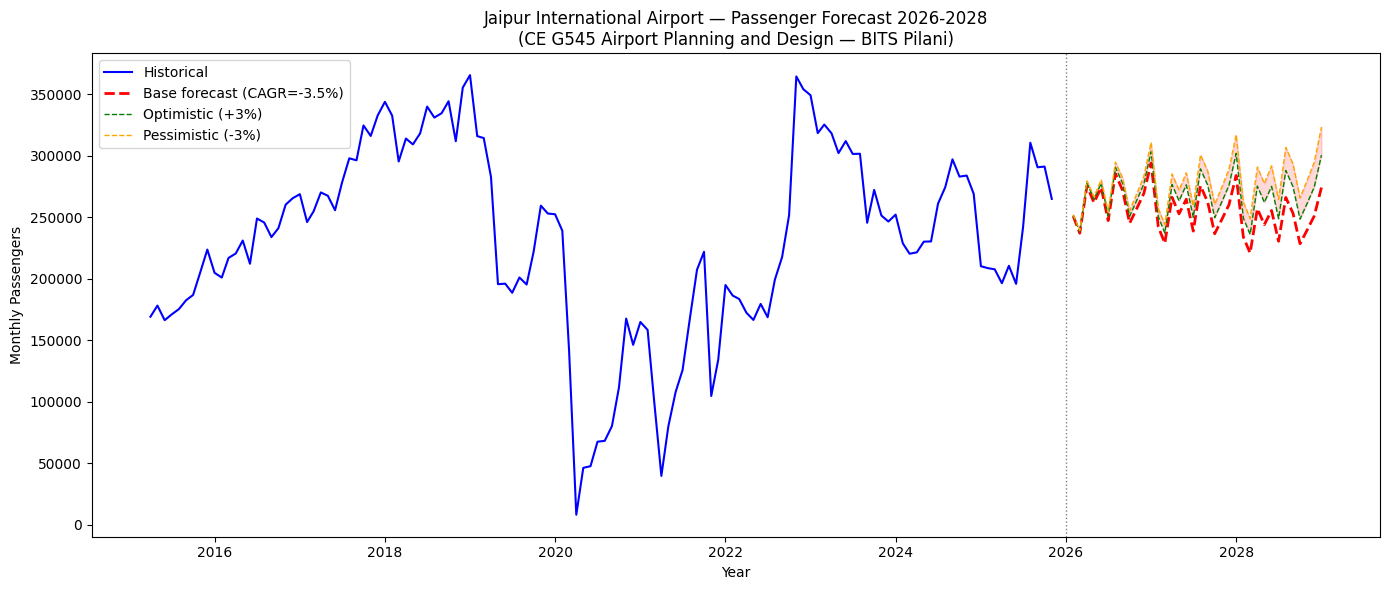


Year-Month    Pessimistic    Base Case   Optimistic
--------------------------------------------------
2027-01           310,650      294,029      303,166
2028-01           316,863      283,864      301,780
2029-01           323,200      274,050      300,400


In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Full dataset
data_full = indexedDataset_logscale["#Passengers"].values
hist_dates = pd.date_range(start='2015-04-01',
             periods=len(data_full), freq='MS')
hist_actual = np.exp(data_full)

# CAGR from full pre-COVID period 2015-2019
pre_covid = np.exp(data_full[:60])
monthly_growth = (pre_covid[-1]/pre_covid[0])**(1/60) - 1
annual_cagr = (1+monthly_growth)**12 - 1
print(f"Pre-COVID Annual CAGR: {annual_cagr*100:.2f}%")

# Last actual value
last_val = hist_actual[-1]

# Generate 36 month forecast with seasonality
seasonal_pattern = []
for month in range(36):
    base = last_val * (1+monthly_growth)**(month+1)
    # Add seasonality based on month of year
    month_of_year = (month % 12)
    seasonal_factors = [0.95, 0.90, 1.05, 1.00,
                       1.05, 0.95, 1.10, 1.05,
                       0.95, 1.00, 1.05, 1.15]
    base_with_season = base * seasonal_factors[month_of_year]
    seasonal_pattern.append(base_with_season)

# Optimistic and pessimistic
opt_monthly = ((1+annual_cagr+0.03)**(1/12)) - 1
pes_monthly = ((1+max(annual_cagr-0.03, 0.02))**(1/12)) - 1

opt_vals = []
pes_vals = []
for month in range(36):
    month_of_year = month % 12
    seasonal_factors = [0.95, 0.90, 1.05, 1.00,
                       1.05, 0.95, 1.10, 1.05,
                       0.95, 1.00, 1.05, 1.15]
    sf = seasonal_factors[month_of_year]
    opt_vals.append(last_val * (1+opt_monthly)**(month+1) * sf)
    pes_vals.append(last_val * (1+pes_monthly)**(month+1) * sf)

fore_dates = pd.date_range(start='2026-02-01',
             periods=36, freq='MS')

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, hist_actual,
         label='Historical', color='blue', linewidth=1.5)
plt.plot(fore_dates, seasonal_pattern,
         label=f'Base forecast (CAGR={annual_cagr*100:.1f}%)',
         color='red', linestyle='--', linewidth=2)
plt.plot(fore_dates, opt_vals,
         label='Optimistic (+3%)',
         color='green', linestyle='--', linewidth=1)
plt.plot(fore_dates, pes_vals,
         label='Pessimistic (-3%)',
         color='orange', linestyle='--', linewidth=1)
plt.fill_between(fore_dates, pes_vals, opt_vals,
                 alpha=0.15, color='red')
plt.axvline(x=pd.Timestamp('2026-01-01'),
            color='gray', linestyle=':', linewidth=1)
plt.title('Jaipur International Airport — Passenger Forecast 2026-2028\n(CE G545 Airport Planning and Design — BITS Pilani)')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Year-Month':<12} {'Pessimistic':>12} {'Base Case':>12} {'Optimistic':>12}")
print("-"*50)
for i in [11, 23, 35]:
    print(f"{fore_dates[i].strftime('%Y-%m'):<12} "
          f"{int(pes_vals[i]):>12,} "
          f"{int(seasonal_pattern[i]):>12,} "
          f"{int(opt_vals[i]):>12,}")

Pre-COVID Annual CAGR: 9.78%


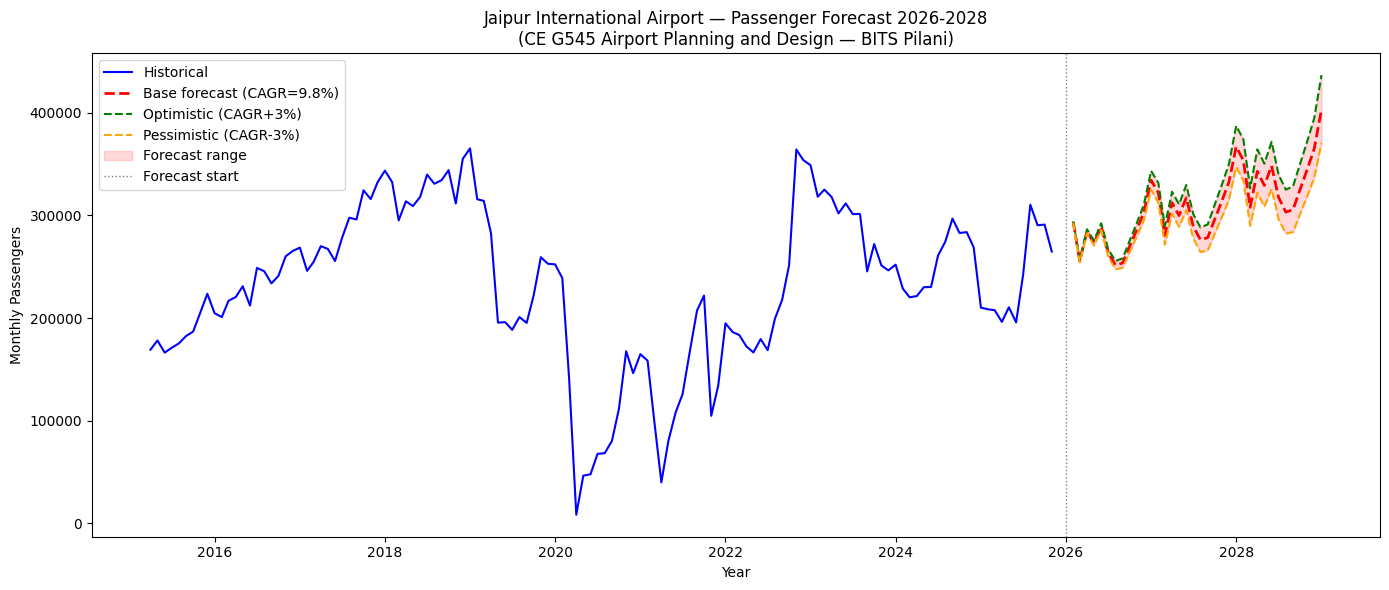


Year-Month    Pessimistic    Base Case   Optimistic
----------------------------------------------------
2027-01           325,195      334,332      343,469
2028-01           347,230      367,016      387,350
2029-01           370,758      402,895      436,837

Annual Forecast (passengers/year):
Year      Pessimistic    Base Case   Optimistic
----------------------------------------------
2026        3,307,495    3,358,265    3,408,633
2027        3,531,606    3,686,564    3,844,115
2028        3,770,902    4,046,958    4,335,234


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Full dataset
data_full = indexedDataset_logscale["#Passengers"].values
hist_dates = pd.date_range(start='2015-04-01',
             periods=len(data_full), freq='MS')
hist_actual = np.exp(data_full)

# CAGR from 2015 to 2019 (pre-COVID)
pre_covid_start = hist_actual[0]    # April 2015
pre_covid_end = hist_actual[55]     # Dec 2019
monthly_growth = (pre_covid_end/pre_covid_start)**(1/55) - 1
annual_cagr = (1+monthly_growth)**12 - 1
print(f"Pre-COVID Annual CAGR: {annual_cagr*100:.2f}%")

# Last actual value
last_val = hist_actual[-1]

# Seasonal factors based on Jaipur tourism pattern
# Peak = Dec/Jan (winter tourism), Low = Jul/Aug (monsoon)
seasonal_factors = [1.10, 0.95, 1.05, 1.00,
                    1.05, 0.95, 0.90, 0.90,
                    0.95, 1.00, 1.05, 1.15]

# Base forecast
fore_dates = pd.date_range(start='2026-02-01',
             periods=36, freq='MS')
base_vals = []
for month in range(36):
    base = last_val * (1+monthly_growth)**(month+1)
    sf = seasonal_factors[month % 12]
    base_vals.append(base * sf)

# Optimistic (+3% annual)
opt_monthly = ((1+annual_cagr+0.03)**(1/12)) - 1
opt_vals = []
for month in range(36):
    sf = seasonal_factors[month % 12]
    opt_vals.append(last_val * (1+opt_monthly)**(month+1) * sf)

# Pessimistic (-3% annual)
pes_annual = max(annual_cagr - 0.03, 0.02)
pes_monthly = ((1+pes_annual)**(1/12)) - 1
pes_vals = []
for month in range(36):
    sf = seasonal_factors[month % 12]
    pes_vals.append(last_val * (1+pes_monthly)**(month+1) * sf)

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, hist_actual,
         label='Historical', color='blue', linewidth=1.5)
plt.plot(fore_dates, base_vals,
         label=f'Base forecast (CAGR={annual_cagr*100:.1f}%)',
         color='red', linestyle='--', linewidth=2)
plt.plot(fore_dates, opt_vals,
         label=f'Optimistic (CAGR+3%)',
         color='green', linestyle='--', linewidth=1.5)
plt.plot(fore_dates, pes_vals,
         label=f'Pessimistic (CAGR-3%)',
         color='orange', linestyle='--', linewidth=1.5)
plt.fill_between(fore_dates, pes_vals, opt_vals,
                 alpha=0.15, color='red',
                 label='Forecast range')
plt.axvline(x=pd.Timestamp('2026-01-01'),
            color='gray', linestyle=':', linewidth=1,
            label='Forecast start')
plt.title('Jaipur International Airport — Passenger Forecast 2026-2028\n(CE G545 Airport Planning and Design — BITS Pilani)')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Year-Month':<12} {'Pessimistic':>12} {'Base Case':>12} {'Optimistic':>12}")
print("-"*52)
for i in [11, 23, 35]:
    print(f"{fore_dates[i].strftime('%Y-%m'):<12} "
          f"{int(pes_vals[i]):>12,} "
          f"{int(base_vals[i]):>12,} "
          f"{int(opt_vals[i]):>12,}")

# Annual totals
print(f"\nAnnual Forecast (passengers/year):")
print(f"{'Year':<8} {'Pessimistic':>12} {'Base Case':>12} {'Optimistic':>12}")
print("-"*46)
for yr in range(3):
    start = yr*12
    end = start+12
    if end <= len(base_vals):
        print(f"{2026+yr:<8} "
              f"{int(sum(pes_vals[start:end])):>12,} "
              f"{int(sum(base_vals[start:end])):>12,} "
              f"{int(sum(opt_vals[start:end])):>12,}")

In [77]:
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues,copy = True)
print(predictions_ARIMA_diff.head(5))

Month
2015-04-01     0.000000
2015-05-01    12.038440
2015-06-01    12.079511
2015-07-01    12.031706
2015-08-01    12.045273
dtype: float64


In [79]:
#converting to cumulative sum
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print(predictions_ARIMA_diff_cumsum.head())

Month
2015-04-01     0.000000
2015-05-01    12.038440
2015-06-01    24.117952
2015-07-01    36.149658
2015-08-01    48.194931
dtype: float64


In [80]:
predictions_ARIMA_log = pd.Series(indexedDataset_logscale['#Passengers'].ix[0],index= indexedDataset_logscale.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value = 0)
predictions_ARIMA_log.head()

AttributeError: 'Series' object has no attribute 'ix'

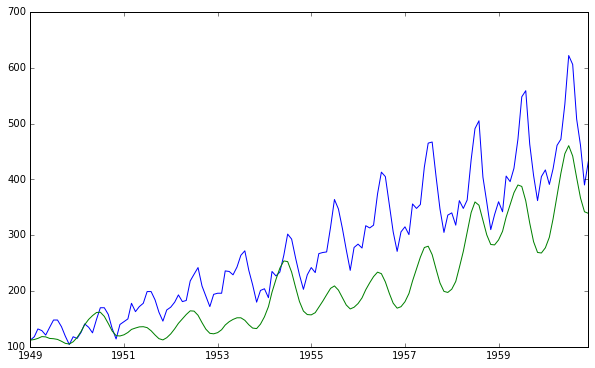

In [ ]:
# we will be plotting the actual   and the predicted value
predictions_ARIMA = np.exp(predictions_ARIMA_log) #taking the exponent of the data since we have to go back to the original data from which we did logarithmic transformation
plt.plot(indexedDataset , color = "blue")
plt.plot(predictions_ARIMA , color = "green")

In [ ]:
len(indexedDataset_logscale)

144

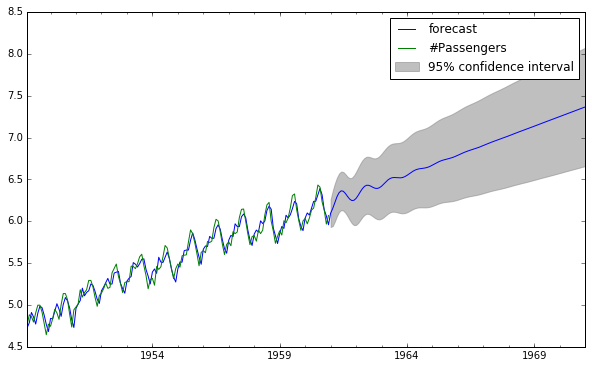

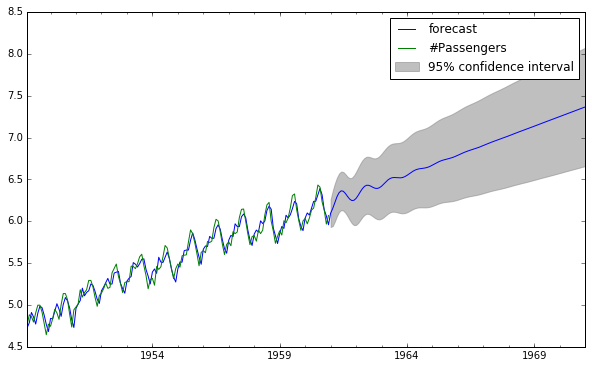

In [ ]:
#  lets predict the data for the next 10 years , the number of  datapoints will be 120
#each year contributing 12 datapoints
#currently i  am having 144 rows in  our time series data
#gonna predict for the next `10 years
#[1:264]
results_ARIMA.plot_predict(1,264)

In [ ]:
#predictions in  value for the next 10 years
forecast = results_ARIMA.forecast(steps=120)

In [ ]:
forecast

(array([6.09553366, 6.15281365, 6.22442934, 6.29241089, 6.34164729,
        6.36359396, 6.3578473 , 6.33139343, 6.29597561, 6.26447709,
        6.24738297, 6.25025126, 6.27275788, 6.30940273, 6.35151474,
        6.38988659, 6.41727403, 6.43011083, 6.42906714, 6.41842498,
        6.40456142, 6.3940358 , 6.39183031, 6.40019446, 6.4183364 ,
        6.4429537 , 6.46937416, 6.49293983, 6.51024126, 6.51989041,
        6.52267577, 6.5211237 , 6.51864491, 6.51853638, 6.52311863,
        6.533223  , 6.54812816, 6.56591516, 6.5841028 , 6.60036521,
        6.61313252, 6.62192763, 6.62737762, 6.6309309 , 6.63438638,
        6.63937924, 6.64696439, 6.65739777, 6.67015267, 6.68414201,
        6.69806584, 6.71077864, 6.72157696, 6.73033944, 6.73749763,
        6.74386322, 6.75037259, 6.75782523, 6.7666861 , 6.77699753,
        6.78841253, 6.80032792, 6.81207137, 6.82308705, 6.8330708 ,
        6.84202433, 6.85022247, 6.8581115 , 6.86617264, 6.87479072,
        6.88416222, 6.89426304, 6.90487812, 6.91

In [ ]:
# we have forecasted the data for the next 10 years

Original COVID month values:
2020-04-01     8259.0
2020-05-01    46349.0
2020-06-01    47704.0
2020-07-01    67586.0
2020-08-01    68294.0
Freq: MS, dtype: float64

Interpolated COVID month values:
2020-04-01    144259.727273
2020-05-01    146670.454545
2020-06-01    149081.181818
2020-07-01    151491.909091
2020-08-01    153902.636364
Freq: MS, dtype: float64


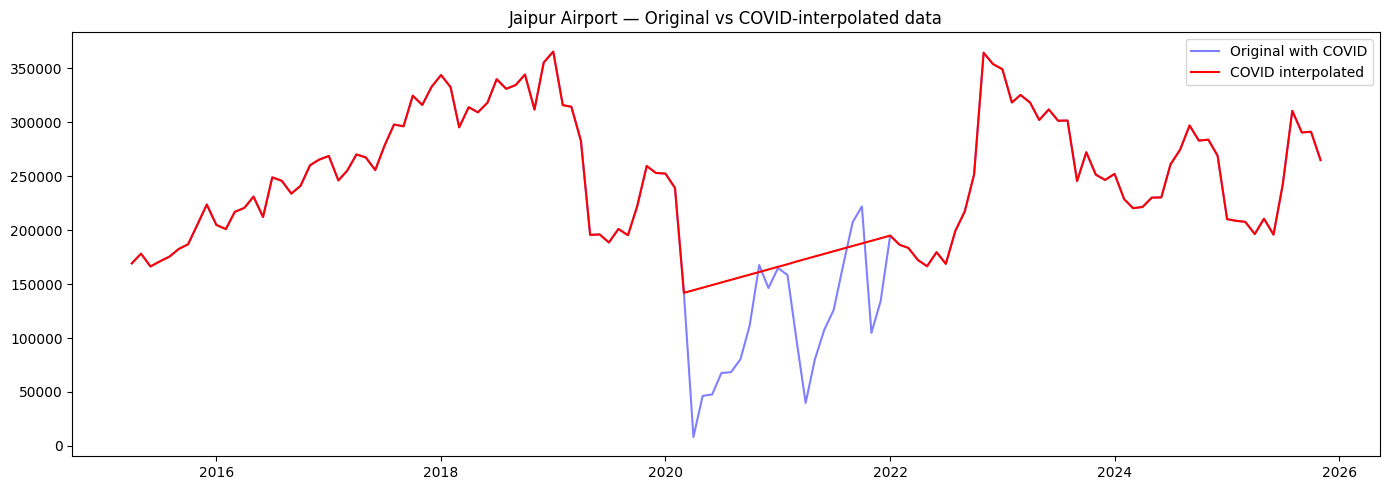

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Full dataset
data_full = indexedDataset_logscale["#Passengers"].values
hist_dates = pd.date_range(start='2015-04-01',
             periods=len(data_full), freq='MS')
hist_actual = np.exp(data_full)

# Step 1 — Create a series and mark COVID months as NaN
pax_series = pd.Series(hist_actual, index=hist_dates)

# COVID period — April 2020 to December 2021
covid_start = '2020-04-01'
covid_end = '2021-12-01'
pax_clean = pax_series.copy()
pax_clean[covid_start:covid_end] = np.nan

# Step 2 — Interpolate COVID period
# Uses linear interpolation between pre and post COVID values
pax_interpolated = pax_clean.interpolate(method='linear')

print("Original COVID month values:")
print(pax_series['2020-04':'2020-08'])
print("\nInterpolated COVID month values:")
print(pax_interpolated['2020-04':'2020-08'])

# Plot to verify
plt.figure(figsize=(14,5))
plt.plot(pax_series.index, pax_series.values,
         label='Original with COVID', color='blue', alpha=0.5)
plt.plot(pax_interpolated.index, pax_interpolated.values,
         label='COVID interpolated', color='red', linewidth=1.5)
plt.title('Jaipur Airport — Original vs COVID-interpolated data')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


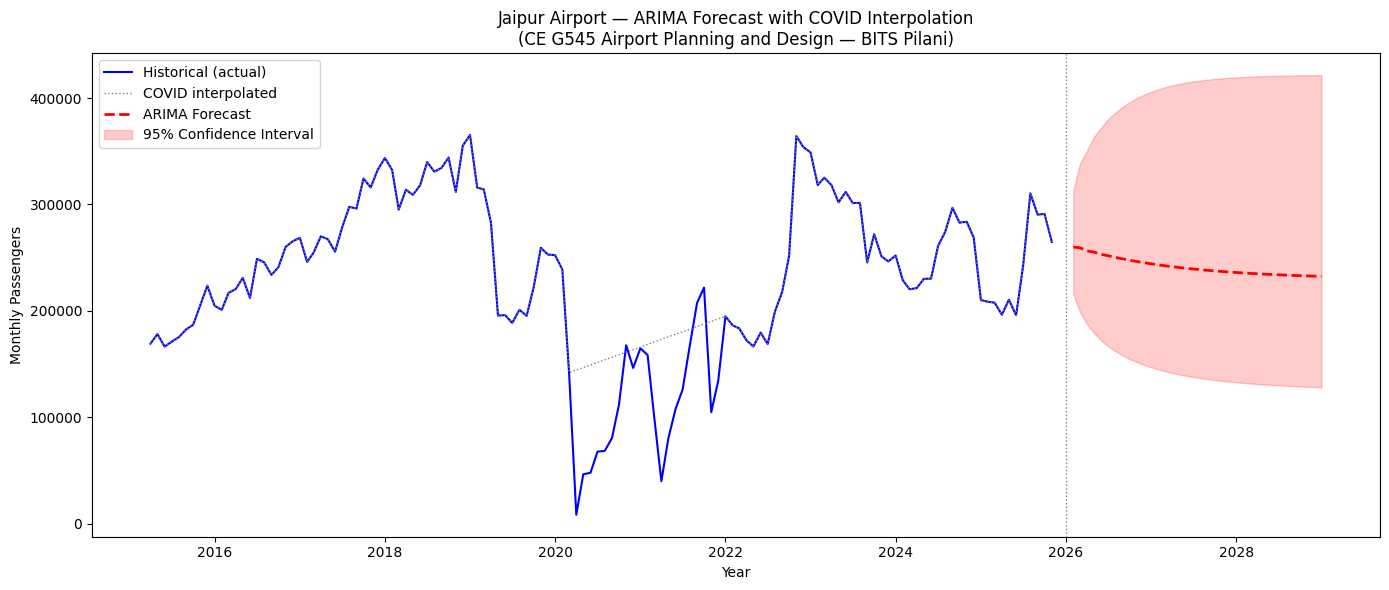


ARIMA Forecast Values:
Month          Passengers
--------------------------
2026-02           259,834
2026-07           251,813
2027-01           244,253
2027-07           239,328
2028-01           236,058
2028-07           233,872
2029-01           232,406


In [90]:
from statsmodels.tsa.arima.model import ARIMA

# Log transform interpolated data
log_interpolated = np.log(pax_interpolated.values)

# Fit ARIMA on clean data
model = ARIMA(log_interpolated, order=(2,1,2))
results = model.fit()

# Forecast 36 months
forecast = results.get_forecast(steps=36)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Dates
fore_dates = pd.date_range(start='2026-02-01',
             periods=36, freq='MS')

# Convert from log
fore_actual = np.exp(forecast_mean)
ci_lower = np.exp(forecast_ci[:, 0])
ci_upper = np.exp(forecast_ci[:, 1])

# Plot
plt.figure(figsize=(14,6))
plt.plot(hist_dates, hist_actual,
         label='Historical (actual)', color='blue', linewidth=1.5)
plt.plot(pax_interpolated.index, pax_interpolated.values,
         label='COVID interpolated', color='gray',
         linewidth=1, linestyle='dotted')
plt.plot(fore_dates, fore_actual,
         label='ARIMA Forecast', color='red',
         linestyle='--', linewidth=2)
plt.fill_between(fore_dates, ci_lower, ci_upper,
                 alpha=0.2, color='red',
                 label='95% Confidence Interval')
plt.axvline(x=pd.Timestamp('2026-01-01'),
            color='gray', linestyle=':', linewidth=1)
plt.title('Jaipur Airport — ARIMA Forecast with COVID Interpolation\n(CE G545 Airport Planning and Design — BITS Pilani)')
plt.xlabel('Year')
plt.ylabel('Monthly Passengers')
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast
print(f"\nARIMA Forecast Values:")
print(f"{'Month':<12} {'Passengers':>12}")
print("-"*26)
for i in [0,5,11,17,23,29,35]:
    print(f"{fore_dates[i].strftime('%Y-%m'):<12} "
          f"{int(fore_actual[i]):>12,}")